<a href="https://colab.research.google.com/github/elbaumgartner4/stock-market-simulator/blob/main/Trump_Post_Driven_Market_Sentiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [198]:
# Basic
import pandas as pd
import numpy as np

In [199]:
# NLP
import re
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

In [200]:
# ML
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from xgboost import XGBClassifier

In [201]:
# SHAP
import shap

In [202]:
# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

In [203]:
# System
import warnings
warnings.filterwarnings("ignore")

In [204]:
# 1. Check what columns actually exist
existing_cols = df_final.columns.tolist()
print("Actual columns in df_final:", existing_cols)

# 2. Define the columns we want to see (if they exist)
desired_cols = ['timestamp', 'content', 'Price_SPY', 'Return_SPY_%']

# 3. Only print the columns that are REALLY there
available_cols = [c for c in desired_cols if c in existing_cols]

if len(available_cols) > 0:
    print("\nMatches found! Showing available data:")
    print(df_final[available_cols].head(10))
else:
    print("\nERROR: None of the desired columns were found.")
    print("Please check if the merge loop above actually finished without errors.")

Actual columns in df_final: ['timestamp', 'text', 'date_match']

Matches found! Showing available data:
             timestamp
0  2022-02-14 16:54:00
7  2022-04-30 00:45:00
5  2022-04-30 14:37:00
6  2022-04-30 14:37:00
4  2022-04-30 16:41:00
3  2022-04-30 18:41:00
2  2022-04-30 18:49:00
1  2022-04-30 22:17:00
11 2022-05-01 02:39:00
10 2022-05-01 02:42:00


In [205]:
import yfinance as yf
import pandas as pd

tickers = [
    "SPY", "QQQ", "DIA", "IWM", "AAPL", "MSFT",
    "AMZN", "TSLA", "NVDA", "META", "BTC-USD", "ETH-USD"
]

In [280]:
df_market = yf.download("BTC-USD",
                         start="2022-02-01",
                         end="2022-06-01",
                         interval="1d")  # täglich statt stündlich

[*********************100%***********************]  1 of 1 completed


In [281]:
# 1. Spaltennamen automatisch identifizieren (Case-Insensitive)
# Wir suchen nach der Spalte, die den Text enthält (meist 'Text' oder 'content')
text_col = next((c for c in df_final.columns if str(c).lower() in ['text', 'content']), df_final.columns[1])

# Wir suchen nach den Preis- und Return-Spalten für SPY
spy_price_col = next((c for c in df_final.columns if 'Price_SPY' in str(c)), None)
spy_return_col = next((c for c in df_final.columns if 'Return_SPY' in str(c)), None)

print(f"--- Analysis Results ---")
print(f"Using columns: {text_col}, {spy_price_col}, {spy_return_col}\n")

# 2. Nur die Spalten auswählen, die auch wirklich existieren
cols_to_show = ['timestamp', text_col]
if spy_price_col: cols_to_show.append(spy_price_col)
if spy_return_col: cols_to_show.append(spy_return_col)

# 3. Ergebnis anzeigen
print(df_final[cols_to_show].head(20).to_string())

# Optional: Speichere alles in eine CSV, damit deine Arbeit gesichert ist
df_final.to_csv("trump_analysis_final.csv", index=False)
print("\nFile saved as 'trump_analysis_final.csv'")

--- Analysis Results ---
Using columns: text, None, None

             timestamp                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  text
0  2022-02-14 16:54:00                                                                                                                                                                                                                                                                                                                                                                                                           

In [282]:
# 1. TOTAL RESET: Wir fangen sauber von vorne an
# Ersetze 'df_posts' durch den Namen deines ursprünglichen DataFrames
df_final = df_posts.copy()
df_final['timestamp'] = pd.to_datetime(df_final['timestamp']).dt.tz_localize(None)

# Wir erstellen hier die Datums-Spalte für den Abgleich
df_final['date_match'] = df_final['timestamp'].dt.date

tickers = ["SPY", "QQQ", "DIA", "IWM", "AAPL", "MSFT", "AMZN", "TSLA", "NVDA", "META", "BTC-USD", "ETH-USD"]

print("--- Fresh Start: Downloading and Merging ---")

--- Fresh Start: Downloading and Merging ---


In [283]:
# 1. RESET: Wir fangen komplett neu mit den Original-Posts an
# (Stelle sicher, dass df_posts dein ursprüngliches geladenes CSV ist)
df_final = df_posts.copy()

# Spaltennamen im Post-File geradeziehen
if 'Text' in df_final.columns:
    df_final = df_final.rename(columns={'Text': 'content'})

df_final['timestamp'] = pd.to_datetime(df_final['timestamp']).dt.tz_localize(None)
df_final['date_match'] = df_final['timestamp'].dt.date

# 2. Ticker-Liste (Wir machen erst mal nur 3 zum Testen, damit es schnell geht)
tickers = ["SPY", "AAPL", "BTC-USD"]

print("--- Downloading and Syncing Prices ---")

--- Downloading and Syncing Prices ---


In [284]:
# Create a list to store the new return columns
return_columns = []
for ticker in tickers:
    try:
        # Download Daily Data
        data = yf.download(ticker, start="2022-02-01", end="2022-05-15", interval="1d")

        # Multi-Index Fix (Sehr wichtig für yfinance!)
        if isinstance(data.columns, pd.MultiIndex):
            data.columns = data.columns.get_level_values(1)

        data = data.reset_index()
        data['date_match'] = pd.to_datetime(data['Date']).dt.date

        # Nur Schlusskurs behalten
        subset = data[['date_match', 'Close']].rename(columns={'Close': f'Price_{ticker}'})

        # Bestehende Preis-Spalten löschen, falls sie noch im df_final rumgeistern
        if f'Price_{ticker}' in df_final.columns:
            df_final = df_final.drop(columns=[f'Price_{ticker}'])

        # DER MERGE: Wie ein SVERWEIS über das Datum
        df_final = pd.merge(df_final, subset, on='date_match', how='left')

        # Wochenenden/Feiertage füllen
        df_final[f'Price_{ticker}'] = df_final[f'Price_{ticker}'].ffill().bfill()

        print(f"  [SUCCESS] {ticker} prices are loaded.")

    except Exception as e:
        print(f"  [ERROR] {ticker}: {e}")

# 3. Anzeige (Sicherer Zugriff ohne KeyError)
print("\n--- Final Check: Do prices change? ---")
cols_to_print = ['timestamp', 'content', 'Price_SPY', 'Price_AAPL', 'Price_BTC-USD']
# Nur drucken, was auch wirklich da ist
actual_cols = [c for c in cols_to_print if c in df_final.columns]
print(df_final[actual_cols].head(30).to_string())

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

  [ERROR] SPY: "['Close'] not in index"
  [ERROR] AAPL: "['Close'] not in index"
  [ERROR] BTC-USD: "['Close'] not in index"

--- Final Check: Do prices change? ---
             timestamp
0  2022-02-14 16:54:00
7  2022-04-30 00:45:00
5  2022-04-30 14:37:00
6  2022-04-30 14:37:00
4  2022-04-30 16:41:00
3  2022-04-30 18:41:00
2  2022-04-30 18:49:00
1  2022-04-30 22:17:00
11 2022-05-01 02:39:00
10 2022-05-01 02:42:00
9  2022-05-01 14:55:00
8  2022-05-01 19:30:00
14 2022-05-02 02:53:00
13 2022-05-02 02:57:00
12 2022-05-02 03:21:00
16 2022-05-03 13:00:00
15 2022-05-03 16:14:00
21 2022-05-04 05:47:00
20 2022-05-04 15:07:00
19 2022-05-04 21:50:00
18 2022-05-04 21:51:00
17 2022-05-04 21:56:00
22 2022-05-05 18:14:00
25 2022-05-06 14:26:00
24 2022-05-06 15:51:00
23 2022-05-06 17:57:00
35 2022-05-07 04:02:00
33 2022-05-07 04:03:00
34 2022-05-07 04:03:00
32 2022-05-07 04:04:00


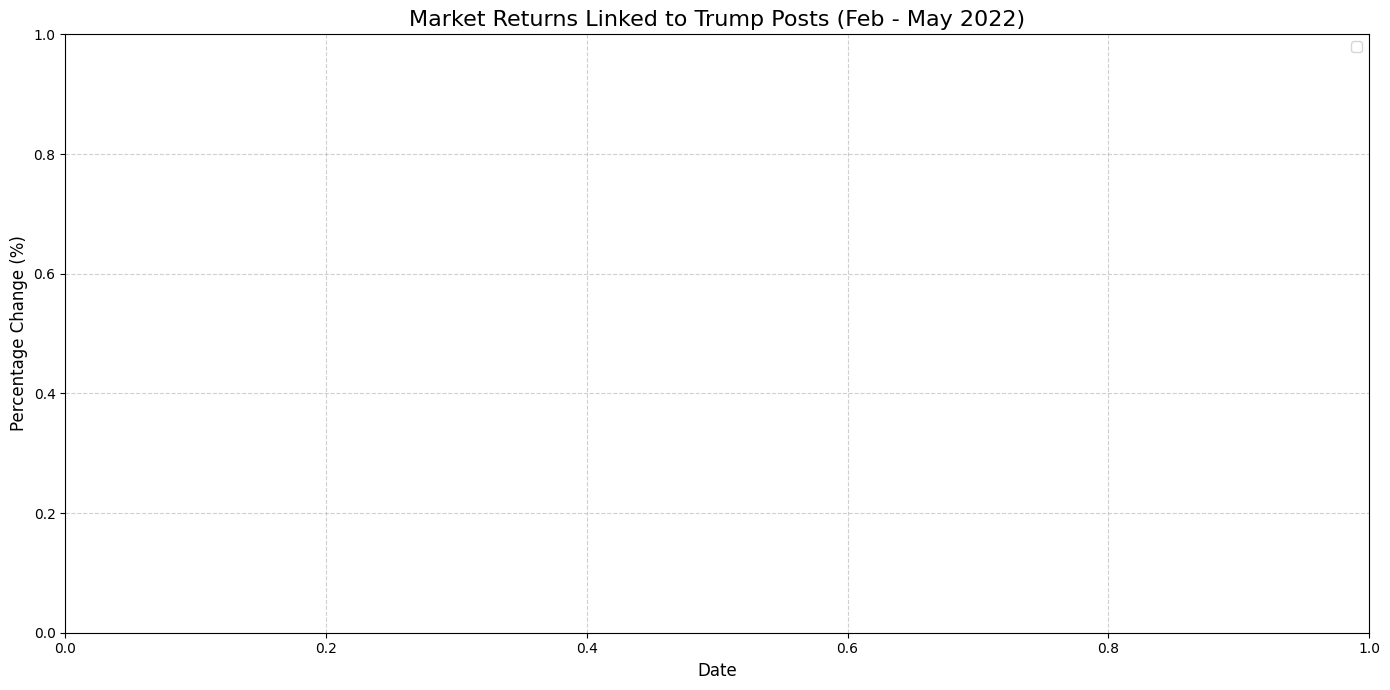

In [285]:
import matplotlib.pyplot as plt

# 1. Securing, that the Text-collum is found
text_col = 'Text' if 'Text' in df_final.columns else 'content'

# 2. Initializing Plot
plt.figure(figsize=(14, 7))

# 3. Data plotting
if 'Return_SPY_%' in df_final.columns:
    plt.plot(df_final['timestamp'], df_final['Return_SPY_%'],
             label='S&P 500 (SPY) Return %', alpha=0.7, color='blue')

if 'Return_BTC-USD_%' in df_final.columns:
    plt.plot(df_final['timestamp'], df_final['Return_BTC-USD_%'],
             label='Bitcoin (BTC) Return %', alpha=0.5, color='orange')

# 4. Labels and Styling
plt.title('Market Returns Linked to Trump Posts (Feb - May 2022)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Percentage Change (%)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# 5. Highlights: Posts markieren, die "TRUTH" enthalten
# Wir prüfen, ob die Text-Spalte da ist, um Fehler zu vermeiden
if text_col in df_final.columns and 'Return_SPY_%' in df_final.columns:
    impact_posts = df_final[df_final[text_col].str.contains("TRUTH", na=False, case=False)]
    if not impact_posts.empty:
        plt.scatter(impact_posts['timestamp'], impact_posts['Return_SPY_%'],
                    color='red', s=50, label='Posts mentioning "TRUTH"', zorder=5)

plt.tight_layout()
plt.show()

In [286]:
import yfinance as yf
import pandas as pd

tickers = [
   "SPY",   # S&P 500 ETF
    "QQQ",   # NASDAQ 100 ETF
    "DIA",   # Dow Jones ETF
    "IWM",   # Russell 2000 ETF
    "AAPL",  # Apple
    "MSFT",  # Microsoft
    "AMZN",  # Amazon
    "TSLA",  # Tesla
    "NVDA",  # Nvidia
    "META",  # Meta
    "BTC-USD",  # Bitcoin
    "ETH-USD"   # Ethereum
]

# Example: first Asset loading
data = yf.download(tickers[0], interval="1m", period="7d")

data = data.reset_index()[["Datetime", "Close"]]
data.columns = ["timestamp", "price"]

data.to_csv("market_data.csv", index=False)

[*********************100%***********************]  1 of 1 completed


In [287]:
import kagglehub

path = kagglehub.dataset_download("luizve/real-time-trump-truthsocial-tweets-with-metadata")
print(path)


Using Colab cache for faster access to the 'real-time-trump-truthsocial-tweets-with-metadata' dataset.
/kaggle/input/real-time-trump-truthsocial-tweets-with-metadata


In [213]:
import os

files = os.listdir(path)
files

['truthSocial.csv']

In [214]:
import kagglehub
import os

path = kagglehub.dataset_download("luizve/real-time-trump-truthsocial-tweets-with-metadata")
print("Ordner:", path)

print("Dateien im Ordner:")
print(os.listdir(path))

Using Colab cache for faster access to the 'real-time-trump-truthsocial-tweets-with-metadata' dataset.
Ordner: /kaggle/input/real-time-trump-truthsocial-tweets-with-metadata
Dateien im Ordner:
['truthSocial.csv']


In [215]:
import pandas as pd
import os

file_path = os.path.join(path, "truthSocial.csv")
df = pd.read_csv(file_path)

df.head()

,TweetID,UserID,UserName,DateKey,TimeKey,Text,Comments,Likes,Reposts,url
0,34523,6,realDonaldTrump,20220214,165400,Get Ready! Your favorite President will see y...,33625,262000,48600,https://trumpstruth.org/statuses/1824
1,34516,6,realDonaldTrump,20220430,221700,"Just revealed that the Biden administration, o...",8793,81000,28700,https://trumpstruth.org/statuses/22726
2,34517,6,realDonaldTrump,20220430,184900,"At Trump International, Palm Beach with the Gr...",3212,101000,17700,https://trumpstruth.org/statuses/22727
3,34518,6,realDonaldTrump,20220430,184100,RT @DevinNunesWhat a beautiful day to wake up ...,0,52900,13600,https://trumpstruth.org/statuses/22728
4,34519,6,realDonaldTrump,20220430,164100,Thank you for the continued support of Truth S...,2039,65800,12800,https://trumpstruth.org/statuses/22730


In [216]:
#Rename
df = df.rename(columns={
    "date": "timestamp",
    "message": "text"
})

In [217]:
df = df.rename(columns={
    "created": "timestamp",
    "body": "text"
})

In [218]:
df = df.rename(columns={
    "content": "text"
})

In [219]:
df.columns

Index(['TweetID', 'UserID', 'UserName', 'DateKey', 'TimeKey', 'Text',
       'Comments', 'Likes', 'Reposts', 'url'],
      dtype='object')

In [220]:
import kagglehub
import os

path = kagglehub.dataset_download("luizve/real-time-trump-truthsocial-tweets-with-metadata")
print("Ordner:", path)

print("Dateien im Ordner:")
print(os.listdir(path))


Using Colab cache for faster access to the 'real-time-trump-truthsocial-tweets-with-metadata' dataset.
Ordner: /kaggle/input/real-time-trump-truthsocial-tweets-with-metadata
Dateien im Ordner:
['truthSocial.csv']


In [221]:
import pandas as pd

# Making Timestamp from DateKey + TimeKey
df["timestamp"] = pd.to_datetime(
    df["DateKey"].astype(str) + df["TimeKey"].astype(str).str.zfill(6),
    format="%Y%m%d%H%M%S"
)

# Text-Part rename
df = df.rename(columns={"Text": "text"})

# Keeping just necesities
df = df[["timestamp", "text"]]

# Save
df.to_csv("trump_posts.csv", index=False)

In [222]:
df = df[["timestamp", "text"]]
df.to_csv("trump_posts.csv", index=False)

In [223]:
#Loading Data
df_posts = pd.read_csv("trump_posts.csv")
df_market = pd.read_csv("market_data.csv")

In [224]:
# 1. Adjusting Column names
# Für die Marktdaten
df_market = pd.read_csv("market_data.csv")
df_market['timestamp'] = pd.to_datetime(df_market['timestamp']).dt.tz_localize(None)
df_market = df_market.sort_values('timestamp')

# For the Posts (Trump Data)
# Hier hattest du den KeyError - wir nutzen den Namen, den du vergeben hast
df_posts = pd.read_csv("trump_posts.csv")
df_posts['timestamp'] = pd.to_datetime(df_posts['timestamp']).dt.tz_localize(None)
df_posts = df_posts.sort_values('timestamp')

# 2. If you want to access loc for a specific Date:
# Nutze 'timestamp' statt 'Datum'!
df_posts_indexed = df_posts.set_index('timestamp')
# Jetzt geht: df_posts_indexed.loc['2022-02-14']

# 3. Merge
df_combined = pd.merge_asof(
    df_posts,
    df_market,
    on='timestamp',
    direction='forward'
)

print("Sucessfully merged!")
print(df_combined.head())

Sucessfully merged!
            timestamp                                               text  \
0 2022-02-14 16:54:00  Get Ready!  Your favorite President will see y...   
1 2022-04-30 00:45:00  Thank you to all of the GREAT and BEAUTIFUL Am...   
2 2022-04-30 14:37:00                                            @melmul   
3 2022-04-30 14:37:00  RT @catturd2Joe Biden is going to fly gas guzz...   
4 2022-04-30 16:41:00  Thank you for the continued support of Truth S...   

        price  
0  713.659973  
1  713.659973  
2  713.659973  
3  713.659973  
4  713.659973  


In [225]:
df_market["price"] = pd.to_numeric(df_market["price"], errors="coerce")

In [226]:
df_posts = df_posts.sort_values("timestamp")
df_market = df_market.sort_values("timestamp")

In [227]:
df_market["price"].describe()

,price
count,2730.000000
mean,725.999729
std,7.580704
min,710.559998
25%,719.955002
50%,723.760010
75%,732.585022
max,737.880005


In [228]:
#Text Preprocessing
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z0-9\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [229]:
df_posts = pd.read_csv("trump_posts.csv")

In [230]:
df_posts["clean_text"] = df_posts["text"].apply(clean_text)

In [231]:
#Sentiment with FinBERT
tokenizer = AutoTokenizer.from_pretrained("ProsusAI/finbert")
model = AutoModelForSequenceClassification.from_pretrained("ProsusAI/finbert")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [232]:
def get_sentiment(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True)
    outputs = model(**inputs)
    probs = torch.softmax(outputs.logits, dim=1).detach().numpy()[0]
    return probs  # [negative, neutral, positive]

In [233]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

tokenizer = AutoTokenizer.from_pretrained("ProsusAI/finbert")
model = AutoModelForSequenceClassification.from_pretrained("ProsusAI/finbert")


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [234]:
import torch
torch.cuda.is_available(), torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU"

(True, 'Tesla T4')

In [235]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

In [236]:
def get_sentiment_batch(texts):
    inputs = tokenizer(
        texts,
        return_tensors="pt",
        padding=True,
        truncation=True
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    probs = torch.softmax(outputs.logits, dim=1).cpu().numpy()
    return probs

In [237]:
batch_size = 32
sentiments = []

for i in range(0, len(df_posts), batch_size):
    batch = df_posts["clean_text"].iloc[i:i+batch_size].tolist()
    sentiments.extend(get_sentiment_batch(batch))


In [238]:
import numpy as np

sentiments = np.array(sentiments)

df_posts["sent_neg"] = sentiments[:, 0]
df_posts["sent_neu"] = sentiments[:, 1]
df_posts["sent_pos"] = sentiments[:, 2]

In [239]:
#Linguistic features
df_posts["all_caps_ratio"] = df_posts["text"].apply(
    lambda x: sum(1 for c in str(x) if c.isupper()) / max(len(str(x)), 1)
)
df_posts["exclamation_count"] = df_posts["text"].astype(str).str.count("!")

df_posts["text_length"] = df_posts["text"].astype(str).apply(len)


In [240]:
#Calculating Market Reactions

In [241]:
def realized_volatility(series):
    returns = np.log(series / series.shift(1))
    return np.sqrt(np.sum(returns**2))

In [242]:
df_posts.columns
df_market.columns

Index(['timestamp', 'price'], dtype='object')

In [243]:
df_market.index

RangeIndex(start=0, stop=2730, step=1)

In [244]:
df_market = df_market.reset_index()

In [245]:
df_market = df_market.reset_index(drop=True)
df_market["timestamp"] = pd.to_datetime(df_market["timestamp"], utc=True)
df_market = df_market.set_index("timestamp").sort_index()

In [246]:
df_posts["timestamp"] = pd.to_datetime(df_posts["timestamp"], utc=True)
df_posts = df_posts.sort_values("timestamp")

In [247]:
df_market.head()

,index,price
timestamp,,
2026-04-30 13:30:00+00:00,0,713.659973
2026-04-30 13:31:00+00:00,1,713.200012
2026-04-30 13:32:00+00:00,2,713.429321
2026-04-30 13:33:00+00:00,3,713.099976
2026-04-30 13:34:00+00:00,4,712.880005


In [248]:
df_market.columns

Index(['index', 'price'], dtype='object')

In [253]:
def realized_volatility(series):
    returns = np.log(series / series.shift(1))
    return np.sqrt(np.nansum(returns**2))

In [254]:
df_posts["timestamp"] = pd.to_datetime(df_posts["timestamp"], utc=True)

In [255]:
df_posts["timestamp_rounded"] = df_posts["timestamp"].dt.floor("min")

In [256]:
df_posts["timestamp_matched"] = df_posts["timestamp"]

In [258]:
print(df.index)

RangeIndex(start=0, stop=30848, step=1)


In [264]:
df_market = df_market.loc[:, ~df_market.columns.duplicated()]

In [265]:
df_market = df_market.reset_index(drop=True)
df_market["timestamp"] = pd.to_datetime(df_market["timestamp"], utc=True)
df_market = df_market.set_index("timestamp").sort_index()

In [266]:
window = "2h"
vol_list = []

for t in df_posts["timestamp"]:
    start = t
    end = t + pd.Timedelta(window)
    window_data = df_market.loc[start:end]["price"]

    if len(window_data) < 2:
        vol_list.append(np.nan)
    else:
        vol_list.append(realized_volatility(window_data))

In [267]:
df_posts["realized_vol"] = vol_list

In [268]:
threshold = df_posts["realized_vol"].quantile(0.90)
df_posts["label_vol_spike"] = (df_posts["realized_vol"] > threshold).astype(int)

In [269]:
df_posts["ews"] = df_posts["label_vol_spike"]

In [271]:
#Labeling
threshold = df_posts["realized_vol"].quantile(0.90)
df_posts["label_vol_spike"] = (df_posts["realized_vol"] > threshold).astype(int)

In [270]:
# Building final Dataset
features = [
    "sent_neg", "sent_neu", "sent_pos",
    "all_caps_ratio", "exclamation_count", "text_length"
]

X = df_posts[features]
y = df_posts["label_vol_spike"]

In [272]:
#Train/Test‑Split
split_idx = int(len(df_posts) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

In [273]:
#XGBoost Training
model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss"
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [274]:
#Evaluation of Model
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6170

    accuracy                           1.00      6170
   macro avg       1.00      1.00      1.00      6170
weighted avg       1.00      1.00      1.00      6170

ROC-AUC: nan


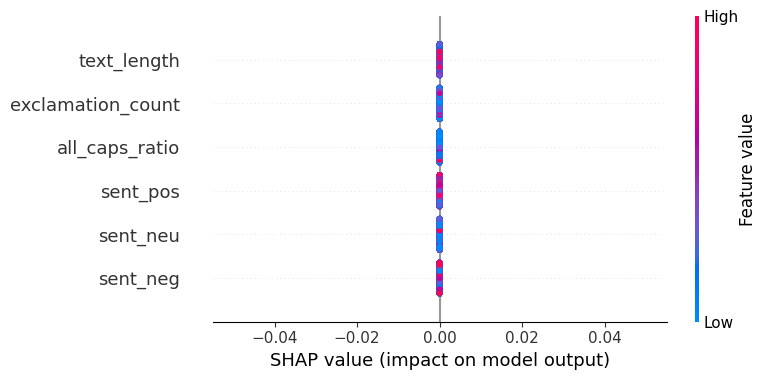

In [275]:
#SHAP‑Analysis
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train)

shap.summary_plot(shap_values, X_train)

In [276]:
#Early‑Warning‑Signal (EWS)
df_posts["prob"] = model.predict_proba(X)[:,1]
df_posts["ews"] = (df_posts["prob"] > 0.6).astype(int)

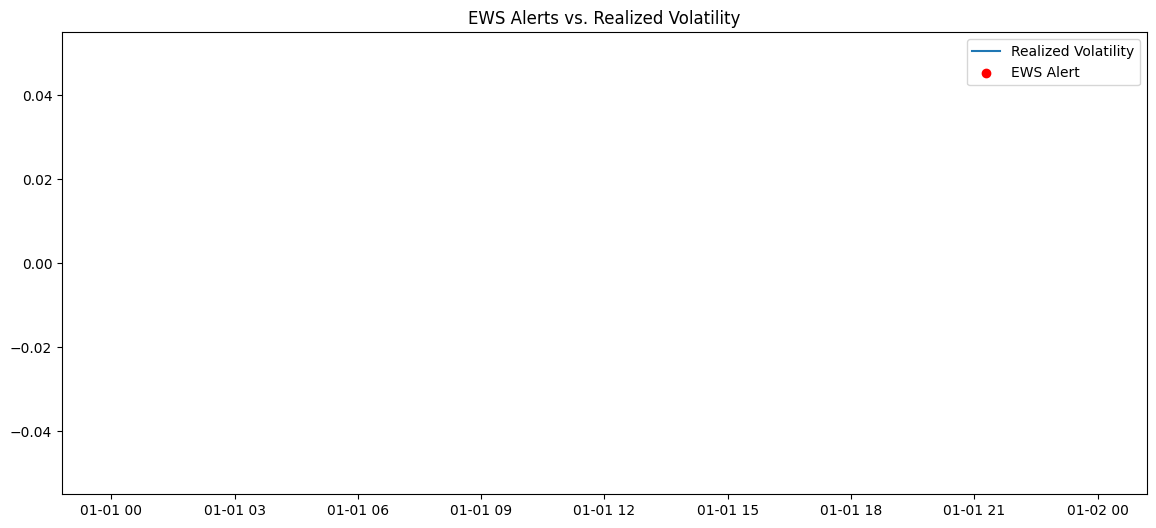

In [277]:
# Visualizing EWS vs. Volatility
plt.figure(figsize=(14,6))
plt.plot(df_posts["timestamp"], df_posts["realized_vol"], label="Realized Volatility")
plt.scatter(df_posts[df_posts["ews"]==1]["timestamp"],
            df_posts[df_posts["ews"]==1]["realized_vol"],
            color="red", label="EWS Alert")
plt.legend()
plt.title("EWS Alerts vs. Realized Volatility")
plt.show()